In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from collections import Counter

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [9]:
json_url = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies.json"

response = requests.get(json_url)

# Перевіряємо чи все добре
print("HTTP status:", response.status_code)

# Перетворюємо текст у список Python
movies = json.loads(response.text)

print("Завантажено записів:", len(movies))

HTTP status: 200
Завантажено записів: 36273


In [10]:
df = pd.DataFrame(movies)

df.head()

,title,year,cast,genres,href,extract,thumbnail,thumbnail_width,thumbnail_height
0,After Dark in Central Park,1900,[],[],None,NaN,NaN,NaN,NaN
1,Boarding School Girls' Pajama Parade,1900,[],[],None,NaN,NaN,NaN,NaN
2,Buffalo Bill's Wild West Parad,1900,[],[],None,NaN,NaN,NaN,NaN
3,Caught,1900,[],[],None,NaN,NaN,NaN,NaN
4,Clowns Spinning Hats,1900,[],[Silent],Clowns_Spinning_Hats,Clowns Spinning Hats is a black-and-white sile...,NaN,NaN,NaN


In [11]:
print("Розмір таблиці:", df.shape)
print("\nПропуски у стовпцях:\n", df.isna().sum())

Розмір таблиці: (36273, 9)

Пропуски у стовпцях:
 title                  0
year                   0
cast                   0
genres                 0
href                1733
extract             1741
thumbnail           5905
thumbnail_width     5905
thumbnail_height    5905
dtype: int64


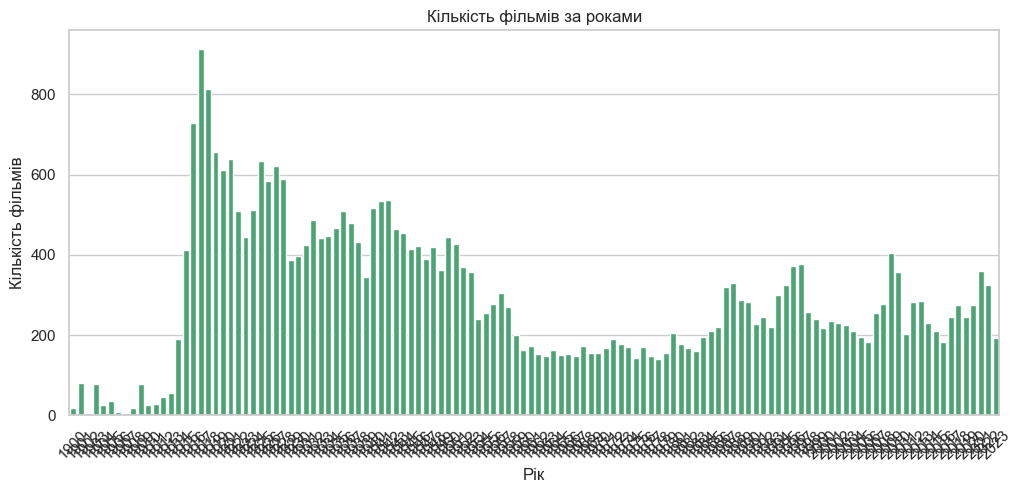

In [13]:
# Підрахунок кількості фільмів за кожен рік
movies_per_year = df['year'].value_counts().sort_index()

# Візуалізація без warning
plt.figure(figsize=(12,5))
sns.barplot(
    x=movies_per_year.index, 
    y=movies_per_year.values, 
    color="mediumseagreen"   # використовується color замість palette
)
plt.title("Кількість фільмів за роками")
plt.xlabel("Рік")
plt.ylabel("Кількість фільмів")
plt.xticks(rotation=45)
plt.show()

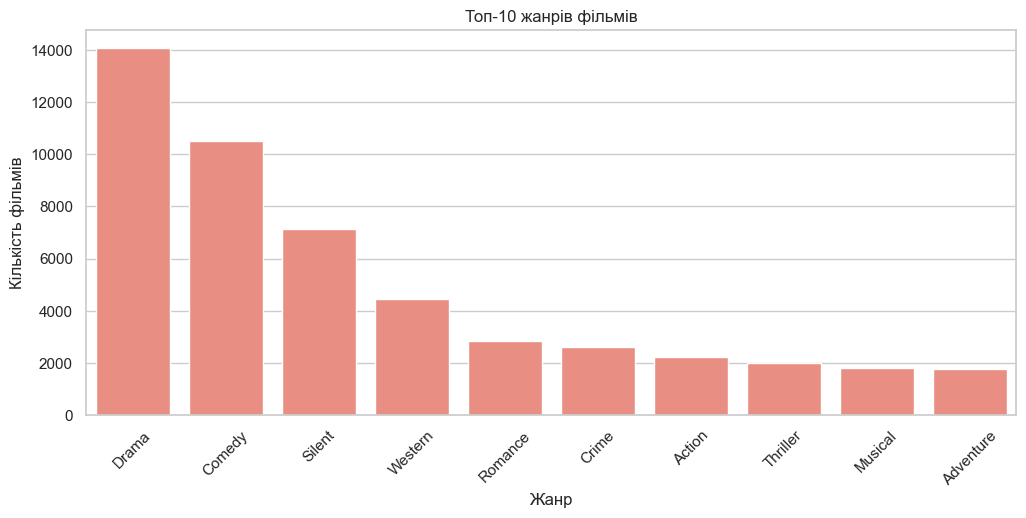

In [17]:
from collections import Counter

# Розпаковуємо всі жанри
all_genres = sum(df['genres'], [])
genre_counts = Counter(all_genres)
top_genres = genre_counts.most_common(10)

# Графік без warning
plt.figure(figsize=(12,5))
sns.barplot(
    x=[g[0] for g in top_genres],
    y=[g[1] for g in top_genres],
    color="salmon"  # замість palette
)
plt.title("Топ-10 жанрів фільмів")
plt.xlabel("Жанр")
plt.ylabel("Кількість фільмів")
plt.xticks(rotation=45)
plt.show()

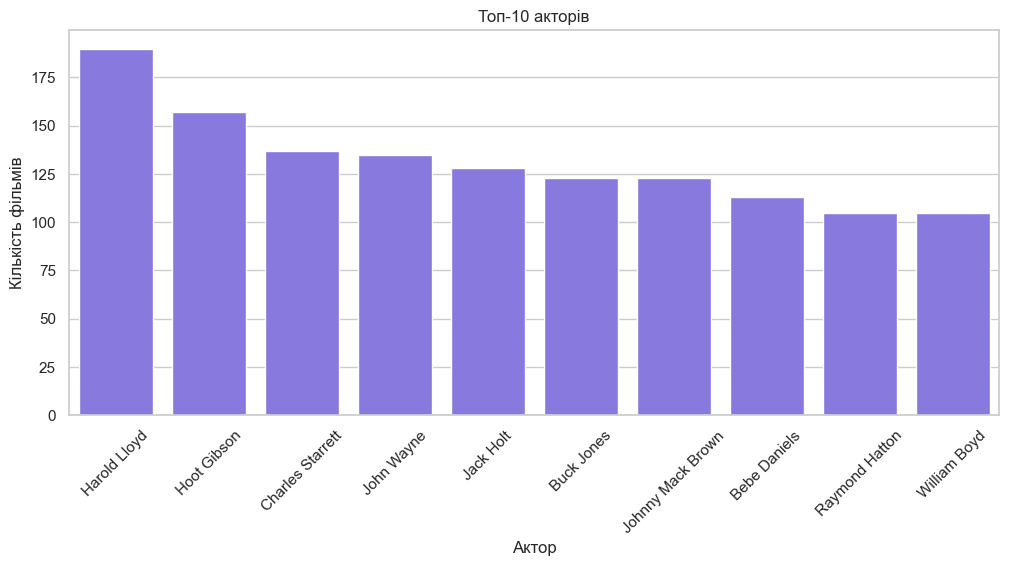

In [18]:
# Розпаковуємо всіх акторів
all_actors = sum(df['cast'], [])
actor_counts = Counter(all_actors)
top_actors = actor_counts.most_common(10)

# Графік без warning
plt.figure(figsize=(12,5))
sns.barplot(
    x=[a[0] for a in top_actors],
    y=[a[1] for a in top_actors],
    color="mediumslateblue"  # замість palette
)
plt.title("Топ-10 акторів")
plt.xlabel("Актор")
plt.ylabel("Кількість фільмів")
plt.xticks(rotation=45)
plt.show()

In [19]:
# - Dataset містить багато фільмів з різних років.
# - Найпопулярніші жанри: (дивись графік).
# - Найактивніші актори: (дивись графік).

In [1]:
# URL файлу на GitHub
json_url = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies.json"

# Завантажуємо файл
response = requests.get(json_url)

# Зберігаємо на комп'ютері в тій же папці, де Notebook
with open("movies.json", "wb") as f:
    f.write(response.content)

print("Файл movies.json успішно збережено у поточній папці!")

NameError: name 'requests' is not defined